# ViSoBERT - Finetuned

**Model**: `visobert` (Finetuned on Vietnamese Fake News)

**Workflow**: Text → BERT → Embedding (768d) → PCA → LogReg → 5-Fold CV

In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


## 1. Load Data

In [5]:
df = pd.read_csv(PROJECT_ROOT / 'data' / 'encoded' / 'final_data_shuffled.csv')
texts = df['text_bert'].fillna('').tolist()
labels = df['label'].values
print(f"Samples: {len(texts)}, Labels: {dict(pd.Series(labels).value_counts())}")

Samples: 4736, Labels: {0: 3929, 1: 807}


## 2. Load Finetuned Model & Extract Embeddings

In [6]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_KEY = 'visobert'
FINETUNED_PATH = PROJECT_ROOT / 'model' / 'bert_embedding' / f'{MODEL_KEY}-finetuned'

if not FINETUNED_PATH.exists():
    raise FileNotFoundError(f"Model not found: {FINETUNED_PATH}\nRun finetuning first!")

tokenizer = AutoTokenizer.from_pretrained(FINETUNED_PATH)
model_cls = AutoModelForSequenceClassification.from_pretrained(FINETUNED_PATH)
model = model_cls.roberta if hasattr(model_cls, 'roberta') else model_cls.bert if hasattr(model_cls, 'bert') else model_cls.base_model
model.to(DEVICE).eval()
print(f"Loaded finetuned model, hidden_size={model.config.hidden_size}")

Loaded finetuned model, hidden_size=768


In [7]:
def extract_embeddings(texts, tokenizer, model, device, max_length=256, batch_size=16):
    embeddings = []
    model.eval()
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="Extracting"):
            batch = texts[i:i+batch_size]
            enc = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors='pt')
            out = model(input_ids=enc['input_ids'].to(device), attention_mask=enc['attention_mask'].to(device))
            embeddings.append(out.last_hidden_state[:, 0, :].cpu().numpy())
    return np.vstack(embeddings)

embeddings = extract_embeddings(texts, tokenizer, model, DEVICE)
print(f"Embeddings: {embeddings.shape}")

del model, model_cls; torch.cuda.empty_cache()

Extracting: 100%|██████████| 296/296 [01:06<00:00,  4.43it/s]

Embeddings: (4736, 768)


## 3. Evaluation Function

In [8]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

def evaluate_dim(X, y, dim):
    if dim < X.shape[1]:
        pca = PCA(n_components=dim, random_state=42)
        X_r = pca.fit_transform(X)
        var = pca.explained_variance_ratio_.sum()
    else:
        X_r, var = X.copy(), 1.0
    X_s = StandardScaler().fit_transform(X_r)
    clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc = cross_val_score(clf, X_s, y, cv=cv, scoring='roc_auc')
    f1 = cross_val_score(clf, X_s, y, cv=cv, scoring='f1')
    prec = cross_val_score(clf, X_s, y, cv=cv, scoring='precision')
    rec = cross_val_score(clf, X_s, y, cv=cv, scoring='recall')
    return {'dim': dim, 'var': var,
            'auc_mean': auc.mean(), 'auc_std': auc.std(),
            'f1_mean': f1.mean(), 'f1_std': f1.std(),
            'prec_mean': prec.mean(), 'prec_std': prec.std(),
            'rec_mean': rec.mean(), 'rec_std': rec.std()}

def plot_metrics(df_results, title_prefix, x_col='dim'):
    metrics = [('auc', 'AUC-ROC'), ('f1', 'F1'), ('prec', 'Precision'), ('rec', 'Recall')]
    df_plot = df_results.sort_values(x_col)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, (m, name) in zip(axes.flat, metrics):
        ax.errorbar(df_plot[x_col], df_plot[f'{m}_mean'], yerr=df_plot[f'{m}_std'], marker='o', capsize=3)
        ax.set_xlabel('Dimension'); ax.set_ylabel(name)
        ax.set_title(f'{title_prefix} - {name}', fontweight='bold')
        ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    
    fig, ax = plt.subplots(figsize=(10, 5))
    for m, name in metrics:
        ax.errorbar(df_plot[x_col], df_plot[f'{m}_mean'], yerr=df_plot[f'{m}_std'], marker='o', capsize=3, label=name)
    ax.set_xlabel('Dimension'); ax.set_ylabel('Score')
    ax.set_title(f'{title_prefix} - All Metrics', fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

## 4. Coarse Search (Step=100)

In [9]:
COARSE_DIMS = [768, 668, 568, 468, 368, 268, 168, 68]

coarse_results = []
for dim in tqdm(COARSE_DIMS, desc="Coarse Search"):
    r = evaluate_dim(embeddings, labels, dim)
    coarse_results.append(r)
    print(f"Dim {dim:4d}: AUC={r['auc_mean']:.4f}, F1={r['f1_mean']:.4f}, Prec={r['prec_mean']:.4f}, Rec={r['rec_mean']:.4f}")

df_coarse = pd.DataFrame(coarse_results)
best_coarse = df_coarse.loc[df_coarse['auc_mean'].idxmax()]
print(f"\nBest coarse: dim={int(best_coarse['dim'])}, AUC={best_coarse['auc_mean']:.4f}")

Coarse Search:  12%|█▎        | 1/8 [00:07<00:54,  7.84s/it]

Dim  768: AUC=0.9282, F1=0.7596, Prec=0.7262, Rec=0.7967


Coarse Search:  25%|██▌       | 2/8 [00:10<00:28,  4.67s/it]

Dim  668: AUC=0.8931, F1=0.7068, Prec=0.6722, Rec=0.7459


Coarse Search:  38%|███▊      | 3/8 [00:12<00:17,  3.52s/it]

...

Dim  268: AUC=0.9367, F1=0.7537, Prec=0.6932, Rec=0.8277


Coarse Search:  88%|████████▊ | 7/8 [00:18<00:01,  1.66s/it]

Dim  168: AUC=0.9559, F1=0.7821, Prec=0.7150, Rec=0.8636


Coarse Search: 100%|██████████| 8/8 [00:18<00:00,  2.35s/it]

Dim   68: AUC=0.9658, F1=0.7858, Prec=0.7072, Rec=0.8847

Best coarse: dim=68, AUC=0.9658


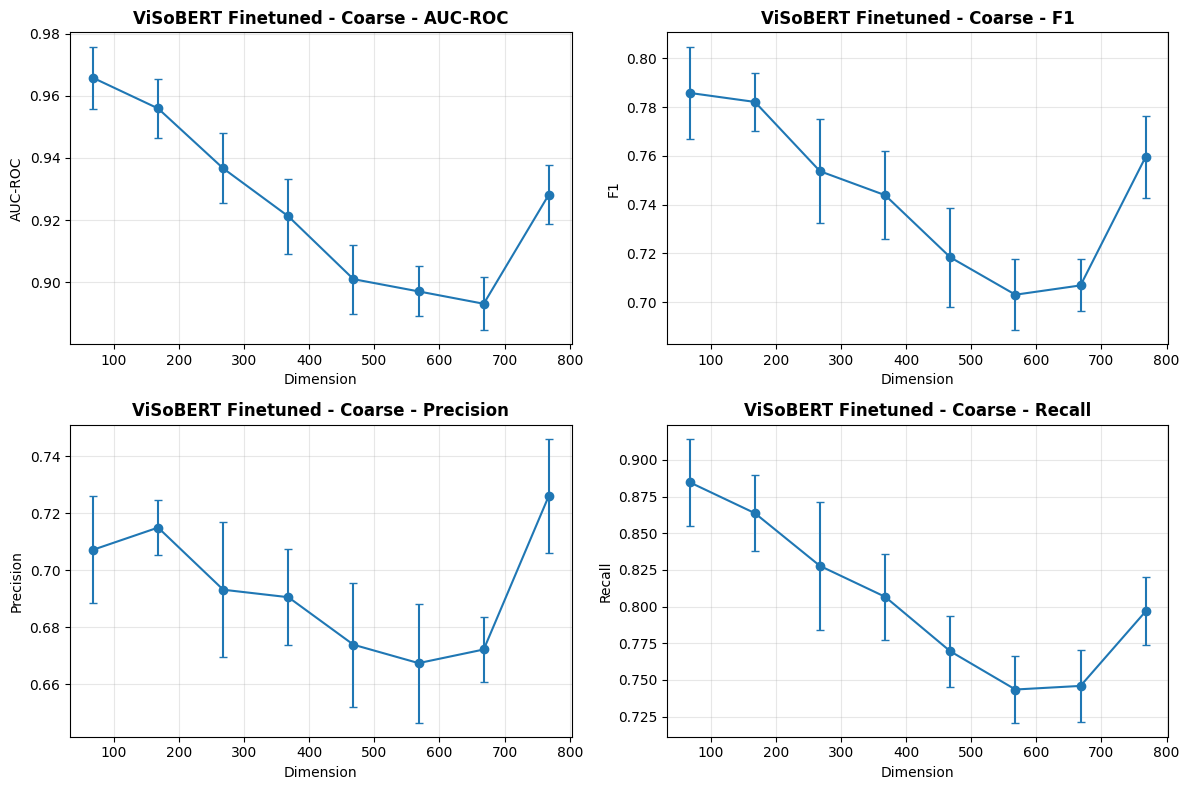

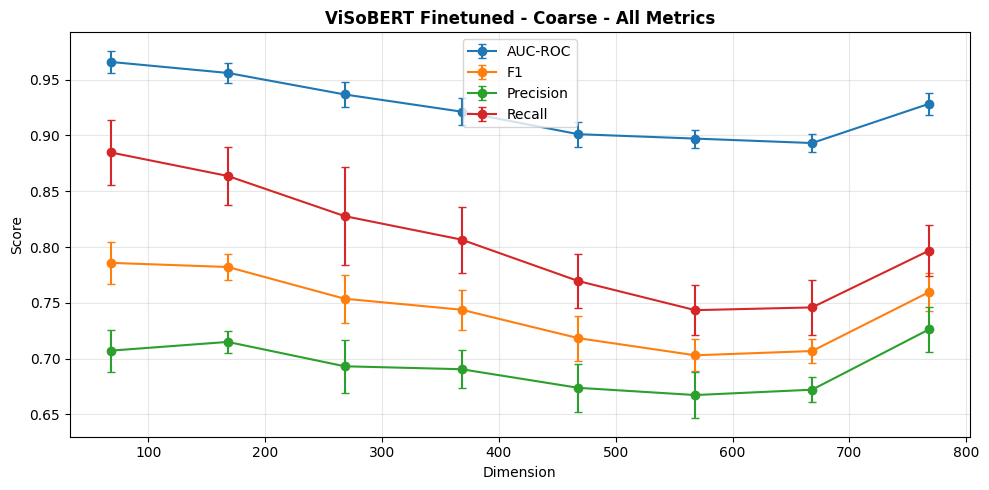

In [10]:
plot_metrics(df_coarse, 'ViSoBERT Finetuned - Coarse')

## 5. Fine Search (Step=10)

In [11]:
best_dim = int(best_coarse['dim'])
fine_start = max(68, best_dim - 50)
fine_end = min(768, best_dim + 50)
FINE_DIMS = list(range(fine_start, fine_end + 1, 10))
print(f"Fine search range: {fine_start} to {fine_end}, dims: {FINE_DIMS}")

fine_results = []
for dim in tqdm(FINE_DIMS, desc="Fine Search"):
    r = evaluate_dim(embeddings, labels, dim)
    fine_results.append(r)
    print(f"Dim {dim:4d}: AUC={r['auc_mean']:.4f}, F1={r['f1_mean']:.4f}, Prec={r['prec_mean']:.4f}, Rec={r['rec_mean']:.4f}")

df_fine = pd.DataFrame(fine_results)
best_fine = df_fine.loc[df_fine['auc_mean'].idxmax()]
print(f"\nBest fine: dim={int(best_fine['dim'])}, AUC={best_fine['auc_mean']:.4f}")

Fine search range: 68 to 118, dims: [68, 78, 88, 98, 108, 118]


Fine Search:  17%|█▋        | 1/6 [00:00<00:02,  1.80it/s]

Dim   68: AUC=0.9658, F1=0.7858, Prec=0.7072, Rec=0.8847


Fine Search:  33%|███▎      | 2/6 [00:01<00:02,  1.99it/s]

Dim   78: AUC=0.9653, F1=0.7881, Prec=0.7127, Rec=0.8822


...

Dim   98: AUC=0.9643, F1=0.7846, Prec=0.7108, Rec=0.8760


Fine Search:  83%|████████▎ | 5/6 [00:02<00:00,  1.92it/s]

Dim  108: AUC=0.9624, F1=0.7907, Prec=0.7229, Rec=0.8735


Fine Search: 100%|██████████| 6/6 [00:03<00:00,  1.90it/s]

Dim  118: AUC=0.9621, F1=0.7865, Prec=0.7132, Rec=0.8772

Best fine: dim=68, AUC=0.9658


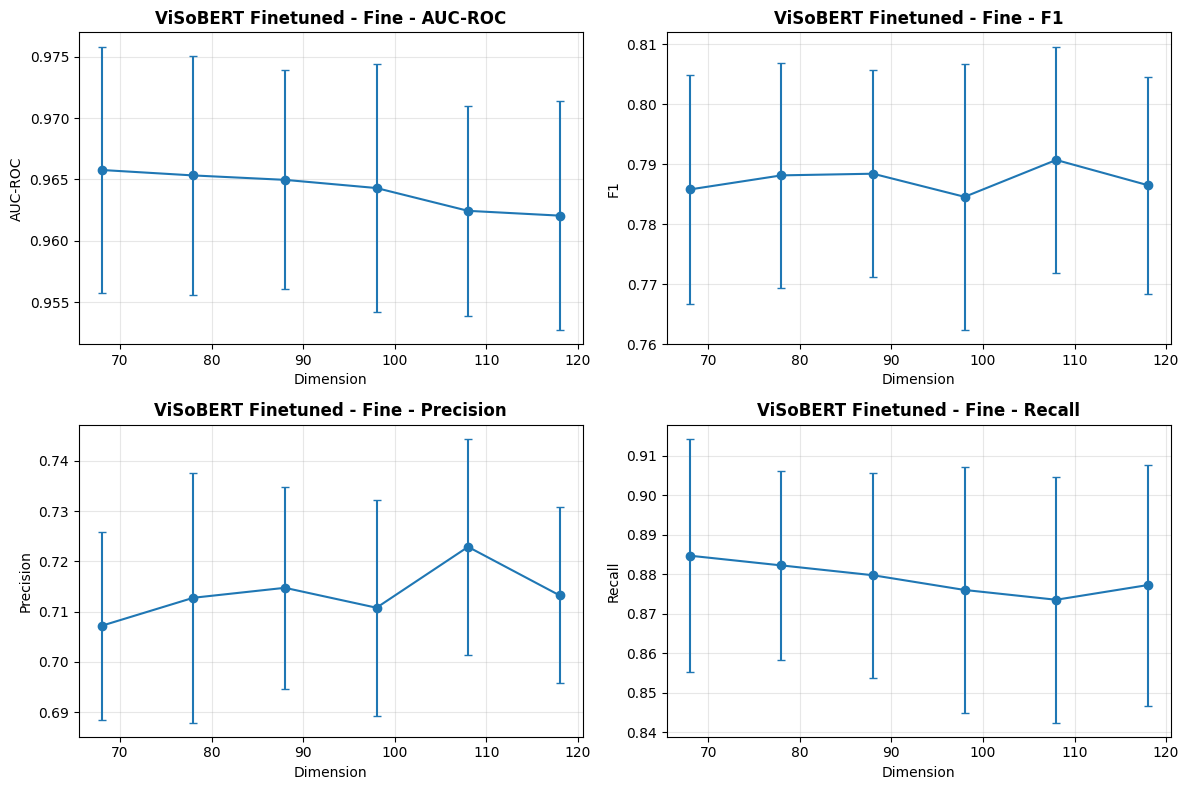

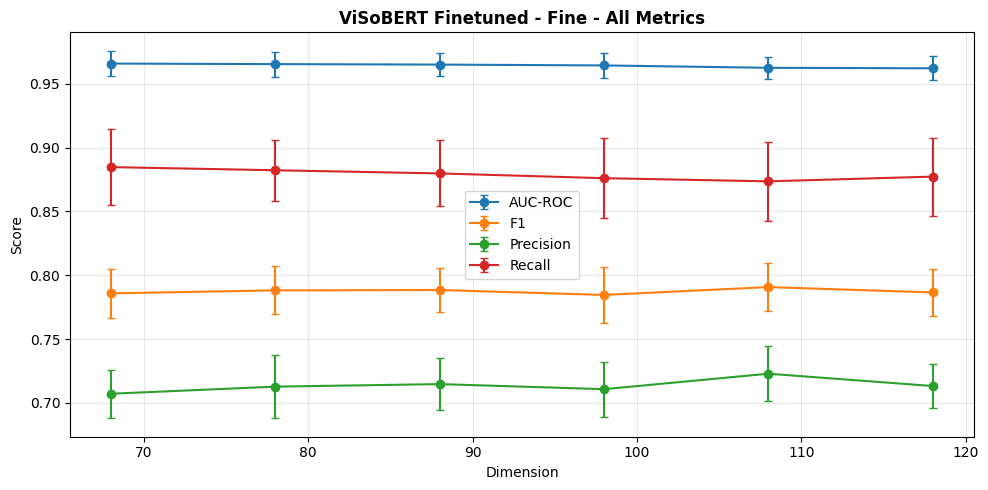

In [12]:
plot_metrics(df_fine, 'ViSoBERT Finetuned - Fine')

## 6. Final Results

In [13]:
OPTIMAL_DIM = int(best_fine['dim'])
print("="*70)
print(f"VISOBERT FINETUNED - OPTIMAL DIM: {OPTIMAL_DIM}")
print("="*70)
print(f"AUC:       {best_fine['auc_mean']:.4f} ± {best_fine['auc_std']:.4f}")
print(f"F1:        {best_fine['f1_mean']:.4f} ± {best_fine['f1_std']:.4f}")
print(f"Precision: {best_fine['prec_mean']:.4f} ± {best_fine['prec_std']:.4f}")
print(f"Recall:    {best_fine['rec_mean']:.4f} ± {best_fine['rec_std']:.4f}")
print(f"Variance:  {best_fine['var']:.2%}")

VISOBERT FINETUNED - OPTIMAL DIM: 68
AUC:       0.9658 ± 0.0101
F1:        0.7858 ± 0.0190
Precision: 0.7072 ± 0.0187
Recall:    0.8847 ± 0.0295
Variance:  90.01%


## 7. Save Optimal Embeddings

In [14]:
pca = PCA(n_components=OPTIMAL_DIM, random_state=42)
embeddings_optimal = pca.fit_transform(embeddings)
print(f"Reduced embeddings: {embeddings_optimal.shape}")

OUTPUT_DIR = PROJECT_ROOT / 'data' / 'encoded' / 'visobert'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
np.save(OUTPUT_DIR / 'finetuned_embeddings.npy', embeddings_optimal)
print(f"Saved to {OUTPUT_DIR / 'finetuned_embeddings.npy'}")
print(f"Shape: {embeddings_optimal.shape} (matches {len(df)} rows in final_data_shuffled.csv)")

Reduced embeddings: (4736, 68)
Saved to d:\Vietnamese-Fake-News-Detection\data\encoded\visobert\finetuned_embeddings.npy
Shape: (4736, 68) (matches 4736 rows in final_data_shuffled.csv)
